# Fine Tuned pretained Chemberta-Attention Map(xAI)

## Data loading and Preprocessing



In [ ]:
import numpy as np
# Reproducibility
np.random.seed(42)

In [ ]:
from google.colab import drive
drive.mount("....")

Mounted at /content/drive


In [ ]:
!pip install deepchem
import deepchem
deepchem.__version__

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 9.2 MB/s eta 0:00:00


wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


'2.5.0'

In [ ]:
import pandas as pd
df=pd.read_excel(".....")
df.head()

,Molecule ChEMBL ID,Smiles,IC50,classLabel,IsValidSMILES,Morgan_FP,Molecule,Fingerprint,PCA1,PCA2,tSNE1,tSNE2,MolecularWeight,Frequency,cleanedMol
0,CHEMBL94,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C,28.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e880b0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.738898,-1.494784,-52.761700,-42.736099,275.352,27,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C
1,CHEMBL207777,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,97.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88190>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.014164,-1.325272,-63.027809,-53.765778,325.364,1,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2
2,CHEMBL205967,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,2420.0,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88270>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.235565,-1.559108,-61.968063,-54.078575,263.293,1,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2
3,CHEMBL60119,Cc1ccc2c(N)c3c(nc2c1)CCCC3,100.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88430>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,2.705664,0.148113,57.758297,-8.911607,212.296,4,Cc1ccc2c(N)c3c(nc2c1)CCCC3
4,CHEMBL294525,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2,290.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e884a0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,3.600017,-0.978574,61.242554,5.783804,341.455,3,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2


In [ ]:
df['classLabel'].value_counts()

,count
classLabel,
0,2330
1,1747


In [ ]:
df_selected= df[['Smiles', 'classLabel']]
df_selected

,Smiles,classLabel
0,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C,1
1,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,1
2,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,0
3,Cc1ccc2c(N)c3c(nc2c1)CCCC3,1
4,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2,1
...,...,...
4072,O=C(Nc1ccc(CN2CCOCC2)cc1C(=O)C(=O)N1C(=O)CCC1=...,1
4073,COc1cccc2c1C=[N+](c1ccccc1C(F)(F)F)CC2.[Br-],0
4074,COc1cccc2cc[n+](-c3ccc(C)cc3)cc12.[Br-],0
4075,COc1ccc(-[n+]2ccc3cccc(OC)c3c2)cc1.[Br-],1


 The following code for roberta tokenizer and chemberta model building is adopted from deepchem's tutorial: (https://github.com/deepchem/deepchem/blob/master/examples/tutorials/Transfer_Learning_With_ChemBERTa_Transformers.ipynb)

In [ ]:
pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 20.1 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw, PyMol, rdFMCS
from rdkit.Chem.Draw import IPythonConsole
from rdkit import rdBase
import numpy as np
import deepchem as dc

In [ ]:
df.to_csv(".....", index=False)

In [ ]:
import deepchem as dc
import pandas as pd
dataset_file = 'inhibitor.csv'
task = ['classLabel']
featurizer_func = dc.feat.ConvMolFeaturizer()
loader = dc.data.CSVLoader(tasks=task, feature_field='cleanedMol', featurizer=featurizer_func)
dataset = loader.create_dataset(dataset_file)

Streaming output truncated to the last 5000 lines.
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[20:26:15] DEPRECATION WARNING: please use GetValence(getExplicit=False)


In [ ]:
transformer = dc.trans.BalancingTransformer(dataset=dataset)
dataset = transformer.transform(dataset)

In [ ]:
from rdkit import Chem

In [ ]:
pip install simpletransformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.8/330.8 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 53.0 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=a47b6ee351def9025afdb55c8b87ba545d9e99568b2bda84d2fd07767d429f35
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
from simpletransformers.classification.classification_model import ClassificationModel


In [ ]:
import os
import numpy as np
import pandas as pd
from typing import List
from rdkit import Chem

In [ ]:
import deepchem as dc
import pandas as pd

task = ['classLabel']
dataset = dc.data.NumpyDataset(X=df['cleanedMol'], y=df['classLabel'])
splitter = dc.splits.RandomSplitter()
frac_train = 0.7
frac_valid = 0.15
frac_test = 0.15

# Split the dataset
train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset, frac_train=frac_train, frac_valid=frac_valid, frac_test=frac_test,seed=42
)

In [ ]:
test_dataset

<NumpyDataset X.shape: (612,), y.shape: (612,), w.shape: (612,), ids: [3356 2744 3859 ... 860 3507 3174], task_names: [0]>

In [ ]:
train_df = train_dataset.to_dataframe()
valid_df = valid_dataset.to_dataframe()
test_df = test_dataset.to_dataframe()

In [ ]:
train_df

,X,y,w,ids
0,Clc1ccc(CN2CCN(c3nccc(NCc4ccccc4)n3)CC2)cc1,0,1.0,1749
1,CCCCNC(=O)Oc1cccc(CN(C)CCCOc2ccc3ccc(=O)oc3c2)c1,1,1.0,2053
2,Cc1cccc(C[n+]2ccc(C(=O)NCCc3c[nH]c4ccccc34)cc2)c1,0,1.0,538
3,CN(C)CCCCCCCCCCCCNc1c2c(nc3ccccc13)CCCC2,1,1.0,438
4,COc1cc2c(cc1OC)SC(C(=O)CCc1cc[n+](Cc3ccsc3)cc1)C2,1,1.0,2685
...,...,...,...,...
2848,CC1=Nc2nc3c(c(N)c2C(c2ccccc2F)C1C(=O)OC1CCC1)C...,1,1.0,2927
2849,COc1cc2c(cc1OC)C(c1ccccc1)N(CCCCCCc1cc(C)nc(C=...,0,1.0,375
2850,CC1CN(C(=O)Oc2ccc(Oc3ccc(C(F)(F)F)cn3)cc2)CC(C)O1,0,1.0,1908
2851,CN(C)Cc1ccc(CSCCCCCCCCCCSCc2ccc(CN(C)C)o2)o1,0,1.0,333


In [ ]:
train_df=train_df[['X','y']]
valid_df=valid_df[['X','y']]
test_df=test_df[['X','y']]

## Cross species evaluation

### Upload and prep for species dataset

Species datasets: eel (CHEMBL4078), cow (CHEMBL4768), mouse (CHEMBL3199), ray (CHEMBL4780), mosquito (CHEMBL2046266), mouse (CHEMBL3198), and independent  human dataset containing molecules not present on  ChEMBL22  were obtained from Vignaux et al(2023) for validation and specificity inferences.





In [ ]:
df_humanIndependent=pd.read_excel(".....")
df_eel=pd.read_excel(".....")
df_mouse=pd.read_excel(".....")
df_cow=pd.read_excel(".....")
df_ray=pd.read_excel(".....")
df_mosquito=pd.read_excel(".....")

In [ ]:
df_humanIndependent = dc.data.NumpyDataset(X=df_humanIndependent['cleanedMol'], y=df_humanIndependent['binary_activities'])
df_eel = dc.data.NumpyDataset(X=df_eel['cleanedMol'], y=df_eel['single-class-label'])
df_mouse = dc.data.NumpyDataset(X=df_mouse['cleanedMol'], y=df_mouse['single-class-label'])
df_cow = dc.data.NumpyDataset(X=df_cow['cleanedMol'], y=df_cow['single-class-label'])
df_ray = dc.data.NumpyDataset(X=df_ray['cleanedMol'], y=df_ray['single-class-label'])
df_mosquito = dc.data.NumpyDataset(X=df_mosquito['cleanedMol'], y=df_mosquito['single-class-label'])

In [ ]:
df_humanIndependent = df_humanIndependent.to_dataframe()
df_eel = df_eel.to_dataframe()
df_mouse = df_mouse.to_dataframe()
df_cow = df_cow.to_dataframe()
df_ray = df_ray.to_dataframe()
df_mosquito = df_mosquito.to_dataframe()

In [ ]:
df_humanIndependent=df_humanIndependent[['X','y']]
df_eel=df_eel[['X','y']]
df_mouse=df_mouse[['X','y']]
df_cow=df_cow[['X','y']]
df_ray=df_ray[['X','y']]
df_mosquito=df_mosquito[['X','y']]

In [ ]:
df_humanIndependent

,X,y
0,COc1cc(N)c(Cl)cc1C(=O)CCC1CCN(Cc2cccc(C)c2)CC1,1
1,CCN(CCCCCn1c(C)cc(=O)n(CCCCCN(CC)Cc2ccccc2C#N)...,1
2,CCN(CCCCCCn1c(C)cc(=O)n(CCCCCCN(CC)Cc2ccccc2C#...,1
3,CCN(CCCCCn1c(=O)c2ccccc2n(CCCCCN(CC)Cc2ccccc2C...,1
4,C[n+]1c2c(c(N)c3ccccc31)CCCC2,0
...,...,...
203,COc1ccc2c(=O)cc(C(=O)Nc3ccc(CN(C)Cc4ccccc4)cc3...,0
204,COc1cc2[nH]c(C(=O)Nc3ccc(CN(C)Cc4ccccc4)cc3)cc...,0
205,CCN(CCCCn1c(C)cc(=O)n(CCCCN(CC)Cc2ccccc2C#N)c1...,1
206,Cc1cc(=O)n(CCCCCNCc2ccccc2C#N)c(=O)n1CCCCCNCc1...,1


## Model optimization

In [ ]:
import tensorflow as tf
import torch
import gc

# Clear session for TensorFlow
tf.keras.backend.clear_session()

# Collect garbage and release unreferenced memory for PyTorch
gc.collect()
torch.cuda.empty_cache()

print("Memory cleared for TensorFlow and PyTorch.")


Memory cleared for TensorFlow and PyTorch.


In [ ]:
!pip install Optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 12.6 MB/s eta 0:00:00


In [ ]:
import os
import optuna
from sklearn.metrics import roc_auc_score
from simpletransformers.classification.classification_model import ClassificationModel
classification_args = {
    'overwrite_output_dir': True,  # Set to True to overwrite the output directory if it exists
}

# Define the objective function for Optuna
def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-6, 1e-3, log=True)
    num_train_epochs = trial.suggest_int("num_train_epochs", 1, 10)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    warmup_steps = trial.suggest_int("warmup_steps", 0, 1000)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.3)
    adam_epsilon = trial.suggest_float("adam_epsilon", 1e-9, 1e-7, log=True)
    # Generate a unique output directory for each trial
    output_dir = f'/content/AChE_transferLearning_trial_{trial.number}'

    # Create and train the model with the given hyperparameters
    model = ClassificationModel('roberta', 'DeepChem/ChemBERTa-77M-MLM', use_cuda=False, args={**classification_args, 'learning_rate': learning_rate, 'num_train_epochs': num_train_epochs, 'train_batch_size': batch_size, 'dropout': dropout, 'warmup_steps': warmup_steps, 'weight_decay': weight_decay, 'adam_epsilon': adam_epsilon})

    model.train_model(train_df, eval_df=valid_df)

    # Evaluate the model and calculate ROC AUC
    eval_results = model.eval_model(valid_df)
    predictions, _ = model.predict(valid_df['X'].tolist())
    roc_auc = roc_auc_score(valid_df['y'].tolist(), predictions)

    # Return ROC AUC for optimization
    return roc_auc

# Create an Optuna study and optimize hyperparameters
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=2)

# Get the best hyperparameters
best_params = study.best_params
print("Best Hyperparameters:", best_params)

# Train the final model with the best hyperparameters
final_model = ClassificationModel('roberta', 'DeepChem/ChemBERTa-10M-MLM', use_cuda=True, args={**classification_args, **best_params})
final_model.train_model(train_df, eval_df=valid_df)


[I 2025-09-04 20:27:22,300] A new study created in memory with name: no-name-26ac2bcd-214e-436f-bb8e-0ad642d2acab
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Running Epoch 5 of 8:   0%|          | 0/357 [00:00<?, ?it/s]

Running Epoch 6 of 8:   0%|          | 0/357 [00:00<?, ?it/s]

Running Epoch 7 of 8:   0%|          | 0/357 [00:00<?, ?it/s]

Running Epoch 8 of 8:   0%|          | 0/357 [00:00<?, ?it/s]

(2856, 0.6022717334246602)

Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-10M-MLM and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1177723655.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlBu_r')  # Compatible with older matplotlib versions


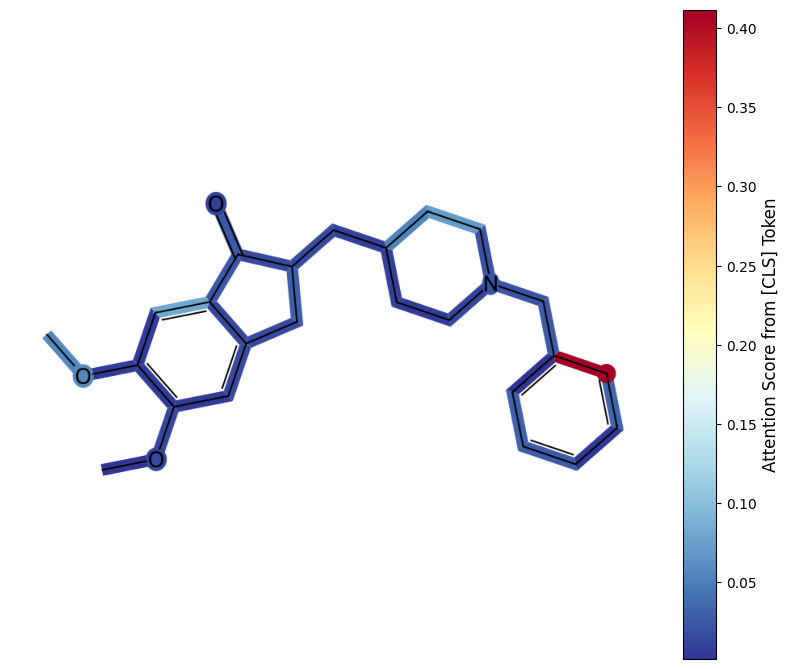

✅ Attention visualization saved to 'chemberta_attention_high_quality.png'


In [ ]:
from transformers import AutoConfig, AutoModel
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from PIL import Image
import io

# -------------------------
# Step 0: Setup
# -------------------------
smiles = "COC1=C(C=C2C(=C1)CC(C2=O)CC3CCN(CC3)CC4=CC=CC=C4)OC"
mol = Chem.MolFromSmiles(smiles)

# -------------------------
# Step 1: Config for attention
# -------------------------
model_name_or_path = final_model.args.model_name  # Ensure final_model is defined in your environment

config = AutoConfig.from_pretrained(model_name_or_path)
config.attn_implementation = "eager"
config.output_attentions = True

# -------------------------
# Step 2: Reload RobertaModel
# -------------------------
hf_model = AutoModel.from_pretrained(model_name_or_path, config=config)

# -------------------------
# Step 3: Fix state_dict keys
# -------------------------
state_dict = final_model.model.state_dict()
new_state_dict = {}

for k, v in state_dict.items():
    if k.startswith("roberta."):
        new_state_dict[k[len("roberta."):]] = v
    else:
        new_state_dict[k] = v

hf_model.load_state_dict(new_state_dict, strict=False)
hf_model.eval()

# -------------------------
# Step 4: Tokenize & run model
# -------------------------
tokenizer = final_model.tokenizer
inputs = tokenizer(smiles, return_tensors="pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hf_model.to(device)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = hf_model(**inputs)

attentions = outputs.attentions
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
seq_len = len(tokens)

# -------------------------
# Step 5: Extract attention
# -------------------------
layer = -1
head = 0
att = attentions[layer][0, head].detach().cpu().numpy()

atom_count = mol.GetNumAtoms()
token_atom_indices = list(range(1, 1 + atom_count))

if max(token_atom_indices) >= seq_len:
    raise ValueError("Token-to-atom mapping out of bounds.")

cls_attention = att[0, token_atom_indices]
cls_attention /= np.sum(cls_attention)

# -------------------------
# Step 6: Prepare color & radii
# -------------------------
norm = mcolors.Normalize(vmin=min(cls_attention), vmax=max(cls_attention))
cmap = cm.get_cmap('RdYlBu_r')

atom_weights = {i: float(cls_attention[i]) for i in range(atom_count)}
colors = {i: tuple(cmap(norm(w))[:3]) for i, w in atom_weights.items()}
radii = {i: 0.6 * atom_weights[i] for i in atom_weights}

# -------------------------
# Step 7: Draw high-res molecule
# -------------------------
drawer = rdMolDraw2D.MolDraw2DCairo(800, 800)  # High resolution 800x800 px
drawer.DrawMolecule(
    mol,
    highlightAtoms=list(atom_weights.keys()),
    highlightAtomColors=colors,
    highlightAtomRadii=radii
)
drawer.FinishDrawing()
mol_img = Image.open(io.BytesIO(drawer.GetDrawingText()))

# -------------------------
# Step 8: Combine with colorbar legend
# -------------------------
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(mol_img)
ax.axis('off')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Attention Score from [CLS] Token', fontsize=12)

plt.tight_layout()
plt.savefig("chemberta_attention_high_quality.png", dpi=300)
plt.show()

print("✅ Attention visualization saved to 'chemberta_attention_high_quality.png'")


In [ ]:
specific_rows=pd.read_csv(".....")

In [ ]:
from transformers import AutoConfig, AutoModel
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from PIL import Image
import io
import os

# -------------------------
# Step 0: Setup model
# -------------------------
model_name_or_path = final_model.args.model_name
config = AutoConfig.from_pretrained(model_name_or_path)
config.attn_implementation = "eager"
config.output_attentions = True

hf_model = AutoModel.from_pretrained(model_name_or_path, config=config)

# Load state dict
state_dict = final_model.model.state_dict()
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith("roberta."):
        new_state_dict[k[len("roberta."):]] = v
    else:
        new_state_dict[k] = v

hf_model.load_state_dict(new_state_dict, strict=False)
hf_model.eval()

# Tokenizer and device
tokenizer = final_model.tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hf_model.to(device)

# Output directory
output_dir = "attention_visualizations"
os.makedirs(output_dir, exist_ok=True)

# -------------------------
# Step 1: Loop through SMILES
# -------------------------
for idx, row in specific_rows.iterrows():
    smiles = row['cleanedMol']
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        print(f"Skipping invalid SMILES at index {idx}: {smiles}")
        continue

    # Tokenize
    inputs = tokenizer(smiles, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = hf_model(**inputs)

    attentions = outputs.attentions
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    seq_len = len(tokens)

    # Get last layer, head 0
    layer = -1
    head = 0
    att = attentions[layer][0, head].detach().cpu().numpy()

    atom_count = mol.GetNumAtoms()
    token_atom_indices = list(range(1, 1 + atom_count))

    if max(token_atom_indices) >= seq_len:
        print(f"⚠️ Token-to-atom mismatch at index {idx}, skipping: {smiles}")
        continue

    cls_attention = att[0, token_atom_indices]
    cls_attention /= np.sum(cls_attention)

    # Normalize attention for coloring
    norm = mcolors.Normalize(vmin=min(cls_attention), vmax=max(cls_attention))
    cmap = cm.get_cmap('RdYlBu_r')

    atom_weights = {i: float(cls_attention[i]) for i in range(atom_count)}
    colors = {i: tuple(cmap(norm(w))[:3]) for i, w in atom_weights.items()}
    radii = {i: 0.6 * atom_weights[i] for i in atom_weights}

    # Draw molecule
    drawer = rdMolDraw2D.MolDraw2DCairo(800, 800)
    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(atom_weights.keys()),
        highlightAtomColors=colors,
        highlightAtomRadii=radii
    )
    drawer.FinishDrawing()
    mol_img = Image.open(io.BytesIO(drawer.GetDrawingText()))

    # Combine with colorbar
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(mol_img)
    ax.axis('off')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Attention Score from [CLS] Token', fontsize=12)

    plt.tight_layout()
    out_path = os.path.join(output_dir, f"mol_{idx}.png")
    plt.savefig(out_path, dpi=300)
    plt.close()

    print(f"✅ Saved attention visualization for index {idx} to '{out_path}'")


Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-10M-MLM and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-460263813.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlBu_r')


✅ Saved attention visualization for index 0 to 'attention_visualizations/mol_0.png'
✅ Saved attention visualization for index 1 to 'attention_visualizations/mol_1.png'
✅ Saved attention visualization for index 2 to 'attention_visualizations/mol_2.png'
✅ Saved attention visualization for index 3 to 'attention_visualizations/mol_3.png'
✅ Saved attention visualization for index 4 to 'attention_visualizations/mol_4.png'
✅ Saved attention visualization for index 5 to 'attention_visualizations/mol_5.png'
✅ Saved attention visualization for index 6 to 'attention_visualizations/mol_6.png'
✅ Saved attention visualization for index 7 to 'attention_visualizations/mol_7.png'
✅ Saved attention visualization for index 8 to 'attention_visualizations/mol_8.png'
✅ Saved attention visualization for index 9 to 'attention_visualizations/mol_9.png'
✅ Saved attention visualization for index 10 to 'attention_visualizations/mol_10.png'
✅ Saved attention visualization for index 11 to 'attention_visualizations/

In [ ]:
best_params

{'learning_rate': 0.000234193618345189,
 'num_train_epochs': 10,
 'batch_size': 32,
 'dropout': 0.24420880640080098,
 'warmup_steps': 110,
 'weight_decay': 0.1056167241960297,
 'adam_epsilon': 1.6886310079699338e-08}

## References


*  https://github.com/deepchem/deepchem/blob/master/examples/tutorials/Transfer_Learning_With_ChemBERTa_Transformers.ipynb
*   https://huggingface.co/DeepChem

*  Ramsundar, B., Eastman, P., Walters, P., Pande, V., Leswing, K., & Wu, Z. (2019). Deep Learning for the Life Sciences. O’Reilly Media. https://www.amazon.com/Deep-Learning-Life-Sciences-Microscopy/dp/1492039837

*  Vignaux, P. A., Lane, T. R., Urbina, F., Gerlach, J., Puhl, A. C., Snyder, S. H., & Ekins, S. (2023). Validation of Acetylcholinesterase Inhibition Machine Learning Models for Multiple Species. Chemical Research in Toxicology, 36(2), 188–201. https://doi.org/10.1021/acs.chemrestox.2c00283


*   Ahmad, W., Simon, E., Chithrananda, S., Grand, G., & Ramsundar, B. (2022). ChemBERTa-2: Towards Chemical Foundation Models (arXiv:2209.01712). arXiv. http://arxiv.org/abs/2209.01712
*   Chithrananda, S., Grand, G., & Ramsundar, B. (2020). ChemBERTa: Large-Scale Self-Supervised Pretraining for Molecular Property Prediction (Version 2). arXiv. https://doi.org/10.48550/ARXIV.2010.09885







